<a href="https://colab.research.google.com/github/prakrut12/QML_Projects/blob/main/Secure_Fraud_Detection_using_QML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install qiskit qiskit-machine-learning pylatexenc pycryptodome scikit-learn

In [16]:
import pandas as pd
import numpy as np
import base64
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.optimizers import COBYLA

from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

In [17]:
def encrypt_transaction(data, key):
    cipher = AES.new(key, AES.MODE_EAX)
    ciphertext, tag = cipher.encrypt_and_digest(data.encode())

    return {
        "ciphertext": base64.b64encode(ciphertext).decode(),
        "nonce": base64.b64encode(cipher.nonce).decode(),
        "tag": base64.b64encode(tag).decode()
    }

def decrypt_transaction(enc_data, key):
    ciphertext = base64.b64decode(enc_data["ciphertext"])
    nonce = base64.b64decode(enc_data["nonce"])
    tag = base64.b64decode(enc_data["tag"])

    cipher = AES.new(key, AES.MODE_EAX, nonce=nonce)
    decrypted = cipher.decrypt_and_verify(ciphertext, tag)

    return decrypted.decode()

key = get_random_bytes(16)

transaction = "Amount=120.45"
encrypted = encrypt_transaction(transaction, key)

print("Encrypted Data:", encrypted)
print("Decrypted Data:", decrypt_transaction(encrypted, key))

Encrypted Data: {'ciphertext': '5tgVoNoCEMcy2EFzGQ==', 'nonce': 'CDEO1nz3Dm7HhXGHDJloYA==', 'tag': 'gH4BRCJN92upMpa0XVXvgQ=='}
Decrypted Data: Amount=120.45


In [18]:
df = pd.read_csv("creditcard.csv")

fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

fraud_sample = fraud.sample(300, random_state=42)
normal_sample = normal.sample(300, random_state=42)

df = pd.concat([fraud_sample, normal_sample]).sample(frac=1)

In [19]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Standard scaling
X_scaled = StandardScaler().fit_transform(X)

# PCA (reduce features for quantum circuit)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Scale to quantum rotation range
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_pca = scaler.fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [20]:
feature_map = ZZFeatureMap(feature_dimension=3, reps=2)
ansatz = RealAmplitudes(3, reps=2)

vqc = VQC(
    sampler=StatevectorSampler(),
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=200)
)

/tmp/ipykernel_39604/1553431016.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=3, reps=2)
/tmp/ipykernel_39604/1553431016.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(3, reps=2)


In [21]:
start = time.time()

vqc.fit(X_train, y_train)

print("Training Time:", time.time() - start)

Training Time: 394.2513301372528


In [22]:
y_pred = vqc.predict(X_test)

print("Quantum Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Quantum Model Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.76      0.98      0.86        60
           1       0.98      0.68      0.80        60

    accuracy                           0.83       120
   macro avg       0.87      0.83      0.83       120
weighted avg       0.87      0.83      0.83       120



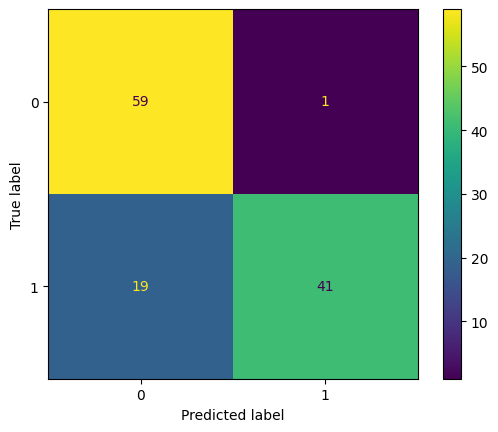

In [23]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()